<div align="center">
<h3></h3>
<h3>BỘ GIÁO DỤC VÀ ĐÀO TẠO</h3>
<h3>TRƯỜNG ĐẠI HỌC ĐẠI HỌC MỎ - ĐỊA CHẤT<h3>

---

<h1>ĐỒ ÁN TỐT NGHIỆP</h1>

<h3>NGÀNH CÔNG NGHỆ THÔNG TIN CHƯƠNG TRÌNH CHẤT LƯỢNG CAO</h3>

<h2>Đề tài: Ứng dụng trí tuệ nhân tạo trong chuẩn đoán và phát hiện bệnh trên lúa dựa vào hình ảnh</h2>

</div>

---

**Họ và tên sinh viên:** Mai Thị Diễm

**Mã sinh viên:** 2121051350

**Lớp:** DCCTCLC66A1

**Giảng viên hướng dẫn:** ThS. Đặng Văn Nam

---
<div align="center">

<h4>Hà Nội - 2025</h4>

</div>

# 1. Giới thiệu về đề tài
## 1.1 Lý do và mục tiêu đề tài:
- **Lý do:** Việc phát hiện bệnh trên lúa vẫn phụ thuộc chủ yếu vào kinh nghiệm thực tế và quan sát bằng mắt thường nên phương pháp này tồn tại nhiều hạn chế. Vậy nên nghiên cứu đề tài này để  hỗ trợ phân tích và nhận diện các đặc điểm bệnh lý trên hình ảnh lá lúa giúp người dân chuẩn đoán kịp thời trong việc phòng chống dịch bệnh.
- **Mục tiêu chính:**
  - Xây dựng mô hình chuẩn đoán và phát hiện bệnh trên lúa dựa vào hình ảnh
  - Đạt được độ chính xác đáng kể trong dự đoán
  - Phát triển giao diện
## 1.2 Giới thiệu về bộ dữ liệu

 Bộ dữ liệu hơn 4600 hình ảnh gồm 3 loại bệnh:

  - Brown Spot: Bệnh đốm nâu
  - Blast: Bệnh đạo ôn
  - Bacterial blight: Bệnh bạc lá

  **Nguồn dữ liệu:**  [Rice Leaf Diseases Dataset](https://data.mendeley.com/datasets/dwtn3c6w6p/1)

#  2. Chuẩn bị dữ liệu

In [ ]:
#liên kết với drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install keras

In [ ]:
!pip install tensorflow

In [ ]:
#Khai báo thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import tensorflow as tf

In [ ]:
#Đọc file rice_leaf_data.csv
data = pd.read_csv('/content/drive/MyDrive/ĐATN/Data/rice_leaf_data.csv')
data.head()

,id,image_name,label,image_link
0,1,BACTERIALBLIGHT_1.jpg,bacterialblight,/content/drive/MyDrive/ĐATN/Data/rice leaf dis...
1,2,BACTERIALBLIGHT_2.jpg,bacterialblight,/content/drive/MyDrive/ĐATN/Data/rice leaf dis...
2,3,BACTERIALBLIGHT_3.jpg,bacterialblight,/content/drive/MyDrive/ĐATN/Data/rice leaf dis...
3,4,BACTERIALBLIGHT_4.jpg,bacterialblight,/content/drive/MyDrive/ĐATN/Data/rice leaf dis...
4,5,BACTERIALBLIGHT_5.jpg,bacterialblight,/content/drive/MyDrive/ĐATN/Data/rice leaf dis...


In [ ]:
#Hiển thị các thuộc tính có trong cột label
data['label'].value_counts()

,count
label,
brownspot,1620
bacterialblight,1604
blast,1460


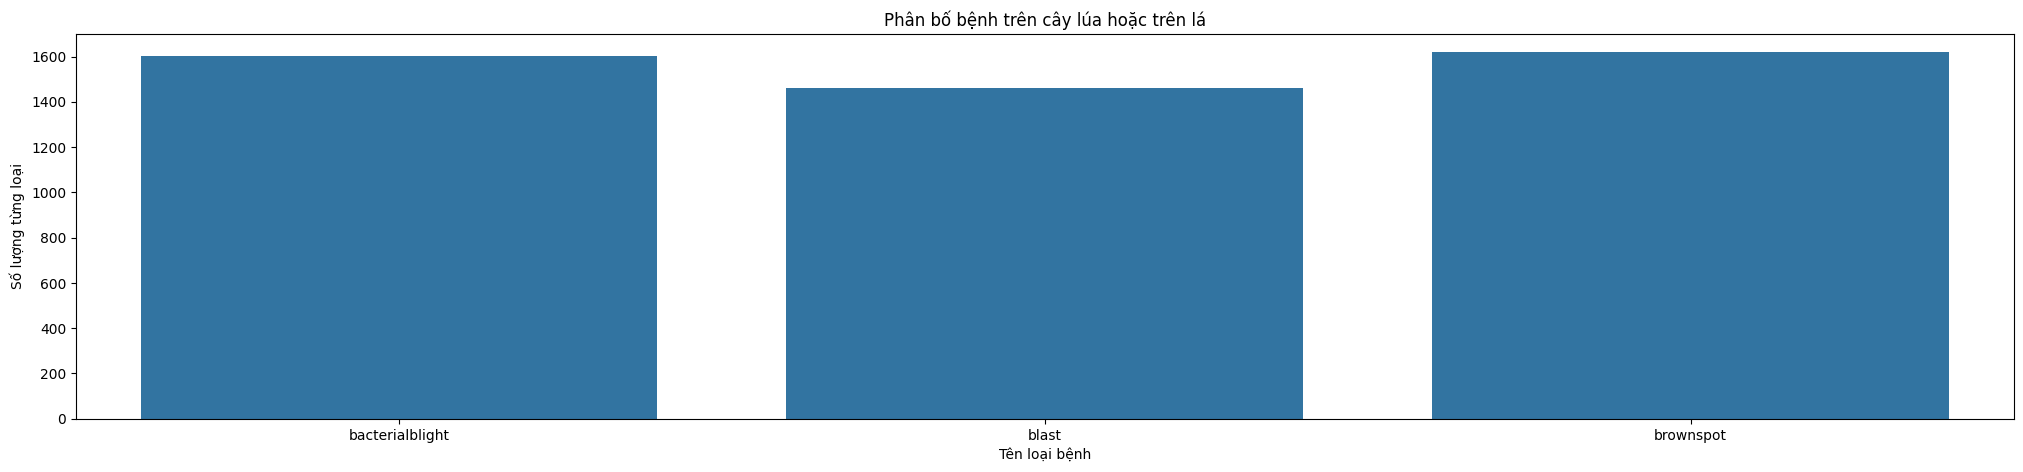

In [ ]:
#Trực quan hóa các thuộc tính label
plt.figure(figsize=(25,5))
sns.countplot(data,x='label')
plt.title("Phân bố bệnh trên cây lúa hoặc trên lá")
plt.xlabel("Tên loại bệnh")
plt.ylabel("Số lượng từng loại")
plt.show()

### Nhận xét:
Từ biểu đồ trên có thể thấy được 3 cột dữ liệu khá cân bằng tránh được việc bị mất cân bằng dữ liệu khiến cho mô hình bị học lệch.

## Hiển thị hình ảnh đặc trưng

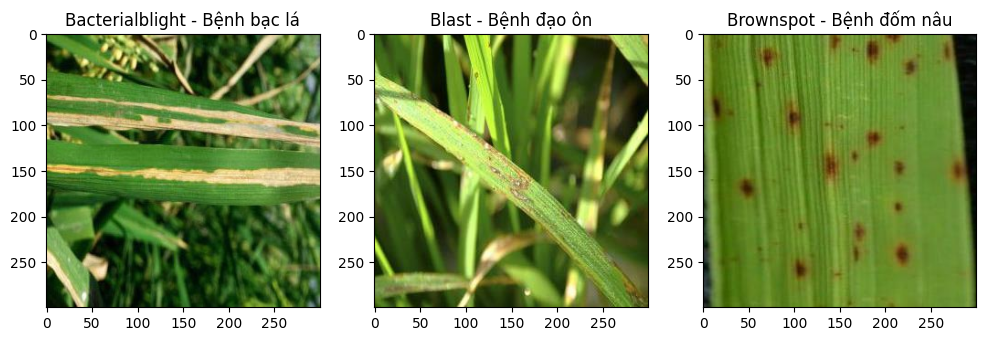

In [ ]:
#Đọc ảnh
img_1 = cv2.imread("/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_dataset/BACTERIALBLIGHT_7.jpg",1)
img_2 = cv2.imread("/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_dataset/BLAST_4682.jpg",1)
img_3 = cv2.imread("/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_dataset/BROWNSPOT_3222.jpg",1)
#Danh sách bệnh
ds = ["Bacterialblight", "Blast", "Brownspot"]

#Hiển thị ảnh
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB))
plt.title('Bacterialblight - Bệnh bạc lá')

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB))
plt.title('Blast - Bệnh đạo ôn')

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_3, cv2.COLOR_BGR2RGB))
plt.title('Brownspot - Bệnh đốm nâu')

plt.show()


### Nhận xét:
Qua những hình ảnh trên có thể thấy được những đặc điểm rõ ràng của từng loại bệnh:

-	Bệnh bạc lá (bacterial blight): lá lúa bị khô cháy, héo rũ, vết bệnh bắt đầu từ mép lá hoặc chóp lá, tạo thành các sọc màu vàng cam hoặc nâu bạc, sau đó lan rộng và làm khô lá.
-	Bệnh đốm nâu (brown spot): lá có các đốm nhỏ hình tròn hoặc bầu dục màu nâu, nâu đỏ trên lá.
-	Bệnh đạo ôn (blast): lá lúa có đốm nhỏ màu xám xanh hoặc trắng, sau phát triển thành hình thoi, tâm màu tro và mép nâu.


## Thu thập đường dẫn và nhãn ảnh


In [ ]:
data_dir = '/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases'
all_image_paths = []
all_labels = []

# Lặp qua các thư mục con trong data_dir
for class_name_folder in os.listdir(data_dir):
    class_dir = os.path.join(data_dir, class_name_folder)
    if os.path.isdir(class_dir): # Đảm bảo đó là một thư mục
        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(class_dir, img_name)
                all_image_paths.append(img_path)
                all_labels.append(class_name_folder)

# In tổng số ảnh và số lượng ảnh cho mỗi lớp
print(f"Tổng số ảnh được thu thập: {len(all_image_paths)}")
print("Số lượng ảnh cho mỗi lớp:")
for label in sorted(list(set(all_labels))):
    print(f"- {label}: {all_labels.count(label)} ảnh")

Tổng số ảnh được thu thập: 4684
Số lượng ảnh cho mỗi lớp:
- Bacterialblight: 1604 ảnh
- Blast: 1460 ảnh
- Brownspot: 1620 ảnh


## Chia dữ liệu thành tập Train, Validation, Test



In [ ]:
from sklearn.model_selection import train_test_split

# Chia tập tạm thời 80% và tập test 20%
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

# Chia tập tạm thời thành tập train (75% tập tạm thời = 60% tập data)
# và tập val (25% tập tạm thời = 20% tập data)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths,
    train_val_labels,
    test_size=0.25,
    random_state=42,
    stratify=train_val_labels
)

print(f"Số lượng mẫu trong tập huấn luyện (60%): {len(train_paths)}")
print(f"Số lượng mẫu trong tập xác thực (20%): {len(val_paths)}")
print(f"Số lượng mẫu trong tập kiểm thử (20%): {len(test_paths)}")

Số lượng mẫu trong tập huấn luyện (60%): 2810
Số lượng mẫu trong tập xác thực (20%): 937
Số lượng mẫu trong tập kiểm thử (20%): 937


In [ ]:
import os

# Tạo cấu trúc thư mục trên Google Drive
# Xác định đường dẫn cho thư mục gốc mới trên Google Drive
split_data_dir = '/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split'

# 2. Tạo thư mục gốc
os.makedirs(split_data_dir, exist_ok=True)
print(f"Thư mục gốc đã được tạo: {split_data_dir}")

# Tạo danh sách các loại tập dữ liệu con
dataset_types = ['train', 'validation', 'test']
# Tạo danh class_name
class_names = ['Bacterialblight', 'Blast', 'Brownspot']

# Lặp qua các loại tập dữ liệu con và tạo thư mục cho từng lớp bệnh
for dtype in dataset_types:
    type_dir = os.path.join(split_data_dir, dtype)
    os.makedirs(type_dir, exist_ok=True)
    print(f"Thư mục {dtype} đã được tạo: {type_dir}")

    # Tạo thư mục con cho từng lớp bệnh
    for class_name in class_names:
        class_dir = os.path.join(type_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)
        print(f"Thư mục lớp {class_name} trong {dtype} đã được tạo: {class_dir}")

print("Cấu trúc thư mục đã được tạo thành công trên Google Drive.")

Thư mục gốc đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split
Thư mục train đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/train
Thư mục lớp Bacterialblight trong train đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/train/Bacterialblight
Thư mục lớp Blast trong train đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/train/Blast
Thư mục lớp Brownspot trong train đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/train/Brownspot
Thư mục validation đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/validation
Thư mục lớp Bacterialblight trong validation đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/validation/Bacterialblight
Thư mục lớp Blast trong validation đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/validation/Blast
Thư mục lớp Brownspot trong validation đã được tạo: /content/drive/MyDrive/ĐATN/Data/rice_le

In [ ]:
# Sao chép ảnh vào các thư mục đã chia mới
import shutil

def copy_images(image_paths, labels, dataset_type, base_dest_dir):
    print(f"\nBắt đầu sao chép ảnh cho tập {dataset_type}...")
    for i, (src_path, label) in enumerate(zip(image_paths, labels)):
        # Lấy tên file ảnh gốc
        img_name = os.path.basename(src_path)
        # Xây dựng đường dẫn đích
        dest_dir = os.path.join(base_dest_dir, dataset_type, label)
        dest_path = os.path.join(dest_dir, img_name)

        # Sao chép ảnh
        try:
            shutil.copy(src_path, dest_path)
            if (i + 1) % 100 == 0: # In tiến độ mỗi 100 ảnh
                print(f"  Đã sao chép {i + 1}/{len(image_paths)} ảnh cho tập {dataset_type}")
        except Exception as e:
            print(f"Lỗi khi sao chép ảnh {src_path} đến {dest_path}: {e}")
    print(f"Hoàn tất sao chép {len(image_paths)} ảnh cho tập {dataset_type}.")

# Sao chép ảnh cho tập huấn luyện
copy_images(train_paths, train_labels, 'train', split_data_dir)

# Sao chép ảnh cho tập xác thực
copy_images(val_paths, val_labels, 'validation', split_data_dir)

# Sao chép ảnh cho tập kiểm thử
copy_images(test_paths, test_labels, 'test', split_data_dir)

print("\nTất cả ảnh đã được sao chép")


Bắt đầu sao chép ảnh cho tập train...
  Đã sao chép 100/2810 ảnh cho tập train
  Đã sao chép 200/2810 ảnh cho tập train
  Đã sao chép 300/2810 ảnh cho tập train
  Đã sao chép 400/2810 ảnh cho tập train
  Đã sao chép 500/2810 ảnh cho tập train
  Đã sao chép 600/2810 ảnh cho tập train
  Đã sao chép 700/2810 ảnh cho tập train
  Đã sao chép 800/2810 ảnh cho tập train
  Đã sao chép 900/2810 ảnh cho tập train
  Đã sao chép 1000/2810 ảnh cho tập train
  Đã sao chép 1100/2810 ảnh cho tập train
  Đã sao chép 1200/2810 ảnh cho tập train
  Đã sao chép 1300/2810 ảnh cho tập train
  Đã sao chép 1400/2810 ảnh cho tập train
  Đã sao chép 1500/2810 ảnh cho tập train
  Đã sao chép 1600/2810 ảnh cho tập train
  Đã sao chép 1700/2810 ảnh cho tập train
  Đã sao chép 1800/2810 ảnh cho tập train
  Đã sao chép 1900/2810 ảnh cho tập train
  Đã sao chép 2000/2810 ảnh cho tập train
  Đã sao chép 2100/2810 ảnh cho tập train
  Đã sao chép 2200/2810 ảnh cho tập train
  Đã sao chép 2300/2810 ảnh cho tập train
  Đã

In [ ]:
 # Xác minh, đếm lại số lượng ảnh trong các thư mục đã chia
# Hàm để đếm số lượng file ảnh trong một thư mục
def count_images_in_dir(directory):
    count = 0
    if os.path.exists(directory):
        for filename in os.listdir(directory):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                count += 1
    return count

# Duyệt qua các tập dữ liệu con và các lớp để in số lượng ảnh
for dtype in dataset_types:
    print(f"Tập {dtype.capitalize()}")
    total_in_type = 0
    for class_name in class_names:
        class_path = os.path.join(split_data_dir, dtype, class_name)
        num_images = count_images_in_dir(class_path)
        total_in_type += num_images
        print(f"  Lớp {class_name}: {num_images} ảnh")
    print(f"  Tổng cộng trong tập {dtype} có: {total_in_type} ảnh")

print("Hoàn thành.")

Tập Train
  Lớp Bacterialblight: 962 ảnh
  Lớp Blast: 876 ảnh
  Lớp Brownspot: 972 ảnh
  Tổng cộng trong tập train có: 2810 ảnh
Tập Validation
  Lớp Bacterialblight: 321 ảnh
  Lớp Blast: 292 ảnh
  Lớp Brownspot: 324 ảnh
  Tổng cộng trong tập validation có: 937 ảnh
Tập Test
  Lớp Bacterialblight: 321 ảnh
  Lớp Blast: 292 ảnh
  Lớp Brownspot: 324 ảnh
  Tổng cộng trong tập test có: 937 ảnh
Hoàn thành.


### Nhận xét

*   Tổng cộng có 4684 hình ảnh được thu thập từ tập dữ liệu gốc, được phân bổ thành ba loại:

      - Bacterialblight: 1604
      - Blast: 1460
      - Brownspot: 1620'.
*  Tập dữ liệu đã được chia thành các tập train, val và test với tỷ lệ 60-20-20.
    * Tập train chứa 2810 hình ảnh (60%).
    * Bộ val chứa 937 hình ảnh (20%).
    * Bộ test chứa 937 hình ảnh (20%).
*   Các hình ảnh được sao chép và sắp xếp thành cấu trúc thư mục mới trên Google Drive. Trong mỗi tập có các lớp như sau:
    * Bộ train (Tổng cộng: 2810 hình ảnh):
        * Bacterialblight: 962 hình ảnh
        * Brownspot: 972 hình ảnh
        * Blast: 876 hình ảnh
    * Bộ val (Tổng cộng: 937 hình ảnh):
        * Bacterialblight: 321 hình ảnh
        * Brownspot: 324 hình ảnh
        * Blast: 292 hình ảnh
    * Bộ test (Tổng cộng: 937 hình ảnh):
        * Bacterialblight: 321 hình ảnh
        * Brownspot: 324 hình ảnh
        * Blast: 292 hình ảnh



In [ ]:
# Kích thước ảnh ban đầu
img = cv2.imread("/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/train/Bacterialblight/BACTERIALBLIGHT_1.jpg",0)
img.shape

(300, 300)

In [ ]:
# Đường dẫn tập train, val, test
train_ds = "/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/train/"
val_ds = "/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/validation/"
test_ds = "/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/test/"

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Rescaling

# Khai báo đường dẫn
split_data_dir = '/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split'

# Khai báo tham số
image_size = (224, 224)
batch_size = 32
class_names = ['Bacterialblight', 'Brownspot', 'Blast']

# Tải và tiền xử lý tập dữ liệu train, validation và test

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_data_dir, 'train'),
    labels='inferred',
    label_mode='categorical',
    class_names=class_names,
    image_size=image_size,
    interpolation='nearest',
    seed=42,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_data_dir, 'validation'),
    labels='inferred',
    label_mode='categorical',
    class_names=class_names,
    image_size=image_size,
    interpolation='nearest',
    seed=42,
    batch_size=batch_size
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(split_data_dir, 'test'),
    labels='inferred',
    label_mode='categorical',
    class_names=class_names,
    image_size=image_size,
    interpolation='nearest',
    seed=42,
    batch_size=batch_size
)

# Tối ưu hóa hiệu suất tập dữ liệu
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2810 files belonging to 3 classes.
Found 937 files belonging to 3 classes.
Found 937 files belonging to 3 classes.


# Huấn luyện mô hình

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras import Model

# Tải mô hình ResNet50 trước huấn luyện
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*image_size, 3))

# Đóng băng các trọng số của base_model
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


print("Hoàn tất")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Hoàn tất


In [ ]:
from tensorflow.keras.optimizers import Adam

# Biên dịch mô hình
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Mô hình biên dịch thành công.")


Mô hình biên dịch thành công.


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Cấu hình ModelCheckpoint để lưu mô hình có trọng số tốt nhất
checkpoint_filepath = '/content/drive/MyDrive/ĐATN/model/resnet50-run/best_model.keras'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Cấu hình EarlyStopping để ngăn mô hình bị quá khớp
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

print("ModelCheckpoint và EarlyStopping callbacks đã được cấu hình")


ModelCheckpoint và EarlyStopping callbacks đã được cấu hình


In [ ]:
history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[model_checkpoint_callback, early_stopping_callback]
)

print("Hoàn thành huấn luyện mô hình")

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.4711 - loss: 1.0475
Epoch 1: val_accuracy improved from -inf to 0.57097, saving model to /content/drive/MyDrive/ĐATN/model/resnet50-run/best_model.weights.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 52s 378ms/step - accuracy: 0.4717 - loss: 1.0466 - val_accuracy: 0.5710 - val_loss: 0.9496
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.6196 - loss: 0.8632
Epoch 2: val_accuracy improved from 0.57097 to 0.57737, saving model to /content/drive/MyDrive/ĐATN/model/resnet50-run/best_model.weights.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 124ms/step - accuracy: 0.6195 - loss: 0.8633 - val_accuracy: 0.5774 - val_loss: 0.9046
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6362 - loss: 0.8315
Epoch 3: val_accuracy improved from 0.57737 to 0.58164, saving model to /content/drive/MyDrive/ĐATN/model/resnet50-run/best_model.weights.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 0.6361 - loss: 0.8316 - val_accura

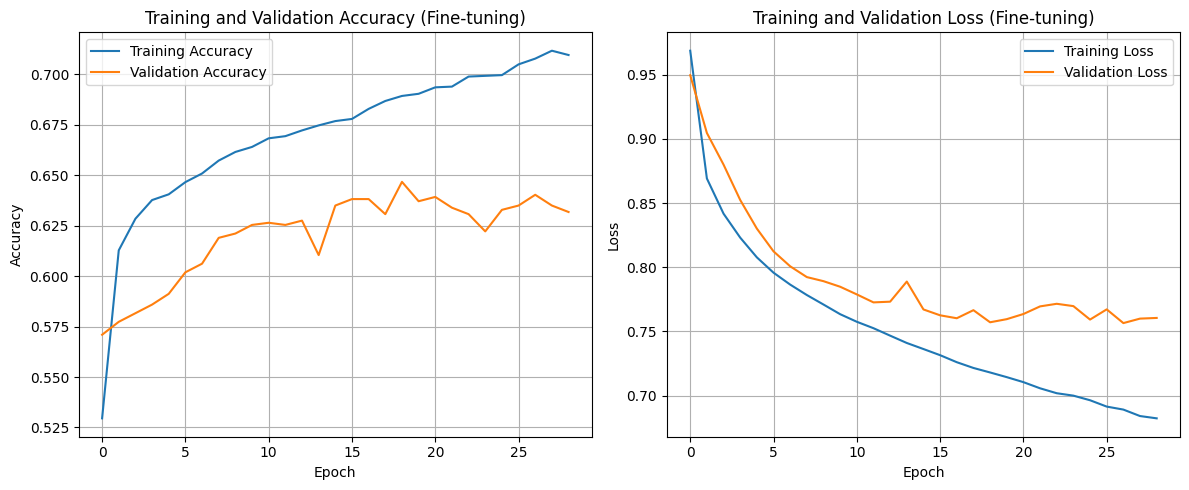

Biểu đồ lịch sử huấn luyện fine-tuning đã được hiển thị.


In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu lịch sử huấn luyện
hist_ft = history.history

# Tạo biểu đồ accuracy và loss
plt.figure(figsize=(12, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist_ft['accuracy'], label='Training Accuracy')
plt.plot(hist_ft['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(hist_ft['loss'], label='Training Loss')
plt.plot(hist_ft['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Fine-tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Nhận xét
* Độ chính xác trên tập huấn luyện tăng liên tục và đạt hơn 71% sau 28 epoch, trong khi độ chính xác trên tập xác thực chỉ cải thiện trong khoảng 10 epoch đầu rồi dừng lại ở mức khoảng 62-64%. Khoảng cách ngày càng lớn giữa hai đường cho thấy mô hình đang học thuộc dữ liệu huấn luyện thay vì học được các đặc trưng tổng quát
* Sai số trên tập xác thực lại chững lại quanh mức 0.76-0.80 và có xu hướng dao động.  Điều này cho thấy mô hình ở đợt huấn luyện này chưa đạt hiệu quả tốt và cần được cải thiện

In [ ]:
# Độ chính xác trên tập test
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Độ chính xác trên tập test: {test_accuracy * 100:.2f}%")


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.6709 - loss: 0.7082
Độ chính xác trên tập test: 64.99%


Đang tạo dự đoán trên tập test và tính toán ma trận nhầm lẫn...


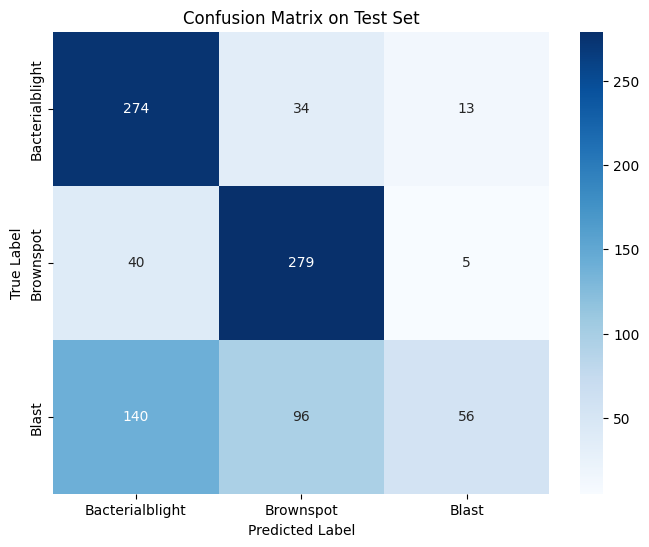

Ma trận nhầm lẫn đã được hiển thị.


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Khởi tạo danh sách để lưu trữ nhãn thực và nhãn dự đoán
y_true = []
y_pred = []

# Lặp qua test_ds để lấy nhãn thực và dự đoán
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1)) # Chuyển one-hot sang chỉ số lớp
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))

# Tính toán ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

### Nhận xét:
 Mô hình có sự chênh lệch rõ rệt trong khả năng nhận diện giữa các loại bệnh. Với bệnh bạc lá và đốm nâu, mô hình đạt kết quả khá tốt với tỷ lệ dự đoán đúng lần lượt là khoảng 85% và 86%. Tuy nhiên, bệnh đạo ôn (blast) lại là điểm yếu lớn nhất của mô hình khi chỉ nhận diện đúng 56 trong tổng số 292 ảnh, tương đương khoảng 19%. Phần lớn ảnh bệnh đạo ôn bị nhầm sang bạc lá (140 ảnh) và đốm nâu (96 ảnh), cho thấy mô hình chưa học được đặc trưng riêng biệt của loại bệnh này.

### 3. Cải thiện hiệu suất mô hình thông qua tăng cường dữ liệu (xoay, lật ảnh)

---



In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import RandomFlip, RandomRotation

# Khởi tạo RandomFlip để lật ngang và dọc
data_augmentation_flip = RandomFlip("horizontal_and_vertical")

# Khởi tạo RandomRotation với một yếu tố 0.2 (tối đa 20% của 2*pi, tức là 72 độ)
data_augmentation_rotation = RandomRotation(factor=0.2)

print("Các lớp đã được tăng cường dữ liệu (RandomFlip và RandomRotation)")

Các lớp đã được tăng cường dữ liệu (RandomFlip và RandomRotation)


### Xây dựng mô hình với tăng cường dữ liệu

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Rescaling # Import Rescaling

# Khởi tạo một mô hình Sequential mới để kết hợp tăng cường dữ liệu và mô hình cơ sở

# Thêm lớp chuẩn hóa pixel thành [0, 1]
normalization_layer = Rescaling(1./255)

model_with_augmentation = Sequential([
    # Thêm các lớp tăng cường dữ liệu
    data_augmentation_flip,
    data_augmentation_rotation,
    normalization_layer,
    # Thêm mô hình cơ sở ResNet50 (đã được tải và đóng băng các trọng số)
    base_model,
    # Thêm lớp GlobalAveragePooling2D để giảm kích thước đặc trưng
    GlobalAveragePooling2D(),
    # Thêm một lớp Dense tùy chỉnh
    Dense(128, activation='relu'),
    # Thêm lớp Dense cuối cùng cho đầu ra dự đoán (số lớp bệnh)
    Dense(len(class_names), activation='softmax')
])

# Hiển thị tóm tắt cấu trúc của mô hình mới
model_with_augmentation.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

### Biên dịch mô hình mới


In [ ]:
from tensorflow.keras.optimizers import Adam

# Biên dịch mô hình sau khi tăng cường dữ liệu xoay, lật
model_with_augmentation.compile(
    optimizer=Adam(learning_rate=0.001), # Sử dụng cùng learning rate ban đầu
    loss='categorical_crossentropy', # Phù hợp cho nhãn phân loại
    metrics=['accuracy'] # Giám sát độ chính xác trong quá trình huấn luyện
)

print("Mô hình đã được biên dịch thành công")

Mô hình đã được biên dịch thành công


## Cấu hình Callbacks cho huấn luyện


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Cấu hình ModelCheckpoint để lưu mô hình tốt nhất
checkpoint_filepath_augmented = '/content/drive/MyDrive/ĐATN/model/resnet50_augmented_run/best_model_augmented.keras'
model_checkpoint_callback_augmented = ModelCheckpoint(
    filepath=checkpoint_filepath_augmented,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Cấu hình EarlyStopping để tránh overfitting
early_stopping_callback_augmented = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

print("ModelCheckpoint và EarlyStopping callbacks đã được cấu hình sau khi tăng cường dữ liệu.")

ModelCheckpoint và EarlyStopping callbacks đã được cấu hình sau khi tăng cường dữ liệu.


### Huấn luyện mô hình đã tăng cường dữ liệu



In [ ]:
# Huấn luyện mô hình với tăng cường dữ liệu...")
history_augmented = model_with_augmentation.fit(
    train_ds,
    epochs=50, # Số epoch bạn muốn huấn luyện (có thể điều chỉnh)
    validation_data=val_ds,
    callbacks=[model_checkpoint_callback_augmented, early_stopping_callback_augmented]
)

print("Quá trình huấn luyện mô hình với tăng cường dữ cường dữ liệu hoàn tất.")

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.4573 - loss: 1.0493
Epoch 1: val_accuracy improved from None to 0.57097, saving model to /content/drive/MyDrive/ĐATN/model/resnet50_augmented_run/best_model_augmented.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/ĐATN/model/resnet50_augmented_run/best_model_augmented.weights.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 42s 340ms/step - accuracy: 0.5249 - loss: 0.9731 - val_accuracy: 0.5710 - val_loss: 0.9362
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6163 - loss: 0.8543
Epoch 2: val_accuracy improved from 0.57097 to 0.57204, saving model to /content/drive/MyDrive/ĐATN/model/resnet50_augmented_run/best_model_augmented.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/ĐATN/model/resnet50_augmented_run/best_model_augmented.weights.h5
88/88 ━━━━━━━━━━━━━━━━━━━━ 15s 171ms/step - accuracy: 0.6103 - loss: 0.8650 - val_accuracy: 0.5720 - val_loss: 0.9081
Epoch 3/50
88/88 ━━━━━━━━

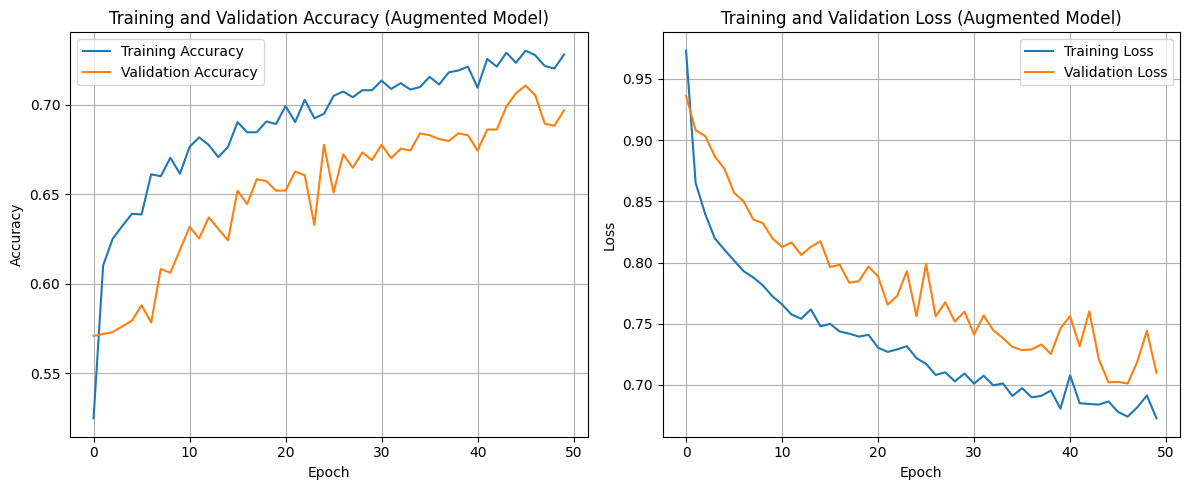

In [ ]:
# Vẽ biểu đồ lịch sử huấn luyện
import matplotlib.pyplot as plt

# Lấy dữ liệu lịch sử huấn luyện từ history_augmented
hist_aug = history_augmented.history

# Tạo biểu đồ accuracy và loss
plt.figure(figsize=(12, 5))

# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist_aug['accuracy'], label='Training Accuracy')
plt.plot(hist_aug['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy (Augmented Model)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(hist_aug['loss'], label='Training Loss')
plt.plot(hist_aug['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss (Augmented Model)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Nhận xét:
* Training Accuracy và Validation Accuracy đều có xu hướng tăng đều đặn, lần lượt đạt khoảng 73% và 69% ở cuối quá trình huấn luyện. Khoảng cách giữa hai đường chỉ vào khoảng 3–5%, cho thấy mô hình không bị overfit nghiêm trọng, và data augmentation đang phát huy hiệu quả rõ rệt trong việc cải thiện khả năng tổng quát hóa.
* Training loss và validation loss đều giảm đều trong 10 epoch đầu, sau đó tiếp tục giảm nhưng chậm hơn và bắt đầu có sự phân kỳ rõ hơn ở nửa sau quá trình huấn luyện. Training loss giảm xuống còn khoảng 0.69 ở cuối trong khi validation loss dừng ở mức khoảng 0.74, đồng thời dao động không ổn định ở nhiều thời điểm.
* Kết quả lần huấn luyện này tuy có tăng nhẹ so với lần đầu nhưng vẫn chưa đạt yêu cầu với accuracy chỉ khoảng 70% và hiện tượng dao động mạnh trên tập xác thực. Điều này cho thấy cấu hình tăng cường dữ liệu và kiến trúc mô hình ở lần này vẫn cần được cải thiện thêm.

In [ ]:
# Đánh giá mô hình đã tăng cường dữ liệu
# Tải trọng số tốt nhất trước khi đánh giá trên tập test
model_with_augmentation.load_weights(checkpoint_filepath_augmented)

# Đánh giá mô hình trên tập test
test_loss_augmented, test_accuracy_augmented = model_with_augmentation.evaluate(test_ds)
print(f"Độ chính xác trên tập test (sau tăng cường dữ liệu): {test_accuracy_augmented * 100:.2f}%")

30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.7343 - loss: 0.6572
Độ chính xác trên tập test (sau tăng cường dữ liệu): 73.43%


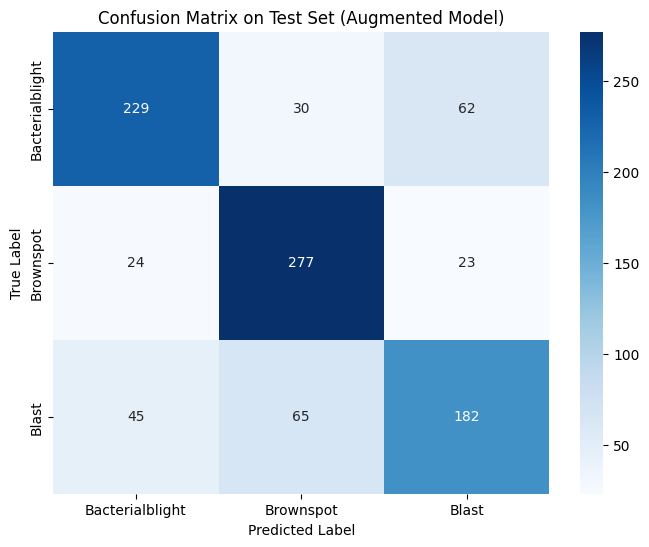

In [ ]:
# Ma trận nhầm lẫn của mô hình đã tăng cường dữ liệu
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


y_true_augmented = []
y_pred_augmented = []

for images, labels in test_ds:
    y_true_augmented.extend(np.argmax(labels.numpy(), axis=1))
    predictions_augmented = model_with_augmentation.predict(images, verbose=0)
    y_pred_augmented.extend(np.argmax(predictions_augmented, axis=1))

cm_augmented = confusion_matrix(y_true_augmented, y_pred_augmented)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_augmented, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set (Augmented Model)')
plt.show()


### Nhận xét:
Bệnh đốm nâu (Brownspot) là loại được nhận diện tốt nhất với 277 trong tổng số 324 ảnh được dự đoán đúng, tương đương khoảng 85%, chỉ nhầm 24 ảnh sang bạc lá và 23 ảnh sang đạo ôn. Bệnh bạc lá (Bacterialblight) đạt mức trung bình khi dự đoán đúng 229 trong 321 ảnh, tương đương khoảng 71%, tuy nhiên có đến 62 ảnh bị nhầm sang đạo ôn và 30 ảnh nhầm sang đốm nâu, đây là mức nhầm lẫn khá cao. Bệnh đạo ôn (Blast) tiếp tục là điểm yếu lớn nhất của mô hình khi chỉ dự đoán đúng 182 trong 292 ảnh, tương đương khoảng 62%, với 65 ảnh bị nhầm sang đốm nâu và 45 ảnh nhầm sang bạc lá.

  => So với lần huấn luyện đầu tiên, kết quả này có cải thiện nhẹ ở bệnh đốm nâu và bạc lá, nhưng bệnh đạo ôn vẫn còn nhầm lẫn rất nhiều.

## Tăng cường dữ liệu: thay đổi ánh sáng và độ tương phản kết hợp với xoay, lật ảnh

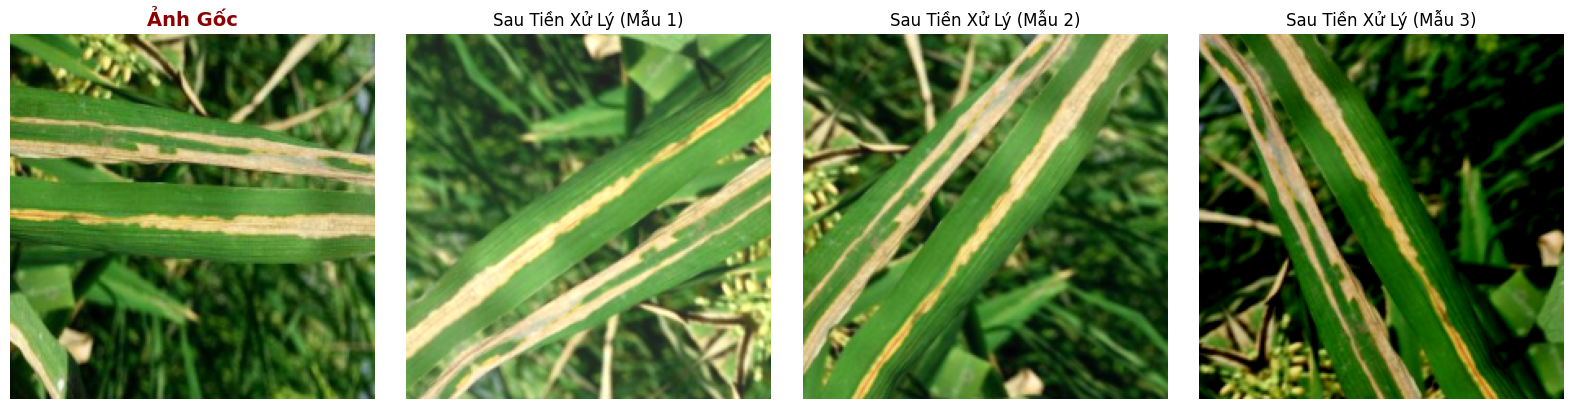

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# Định nghĩa các bước tiền xử lý (Augmentation)
# Giữ nguyên các thông số tối ưu: lật, xoay, sáng, tương phản
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2)
])

def show_original_vs_preprocessed(image_path):
    # 1. Đọc và chuẩn bị ảnh gốc
    img_raw = tf.io.read_file(image_path)
    img_tensor = tf.io.decode_image(img_raw, channels=3)
    img_resized = tf.image.resize(img_tensor, [224, 224])

    # Chuyển kiểu dữ liệu để hiển thị (0-255)
    img_original = tf.cast(img_resized, tf.uint8)

    # Chuẩn bị tensor (thêm batch dimension) để đưa qua layer tiền xử lý
    img_for_aug = tf.expand_dims(tf.cast(img_resized, tf.float32), 0)

    # Thiết lập khung hình hiển thị (1 hàng, 4 cột)
    plt.figure(figsize=(16, 4))

    # Cột 1: Hiển thị Ảnh Gốc
    plt.subplot(1, 4, 1)
    plt.imshow(img_original)
    plt.title("Ảnh Gốc", fontsize=14, fontweight='bold', color='darkred')
    plt.axis("off")

    # Cột 2, 3, 4: Hiển thị Ảnh Sau Tiền Xử Lý
    for i in range(3):
        # training=True để áp dụng các biến đổi ngẫu nhiên
        img_preprocessed = data_augmentation(img_for_aug, training=True)
        img_preprocessed = tf.squeeze(img_preprocessed, 0) # Bỏ batch dimension

        # Đưa dải giá trị về chuẩn 0-255 để matplotlib hiển thị đúng màu
        img_display = np.clip(img_preprocessed.numpy(), 0, 255).astype("uint8")

        plt.subplot(1, 4, i + 2)
        plt.imshow(img_display)
        plt.title(f"Sau Tiền Xử Lý (Mẫu {i+1})", fontsize=12)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Chạy thử nghiệm với 1 ảnh
DUONG_DAN_ANH = "/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/train/Bacterialblight/BACTERIALBLIGHT_7.jpg"

# Bỏ comment dòng dưới để chạy nếu bạn đã điền đúng đường dẫn
show_original_vs_preprocessed(DUONG_DAN_ANH)

In [ ]:

import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Đường dẫn
TRAIN_DIR = '/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/train'
VAL_DIR = '/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/validation'
TEST_DIR = '/content/drive/MyDrive/ĐATN/Data/rice_leaf_diseases_split/test'

# Thư mục để lưu mô hình tốt nhất
SAVE_MODEL_DIR = '/content/drive/MyDrive/ĐATN/model/ResNet50-Run2'
if not os.path.exists(SAVE_MODEL_DIR):
    os.makedirs(SAVE_MODEL_DIR)

MODEL_SAVE_PATH = os.path.join(SAVE_MODEL_DIR, 'resnet50_best_model.keras')

# Tham số cấu hình
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 3
CLASS_NAMES = ['Bacterialblight', 'Blast', 'Brownspot']

In [ ]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# Tối ưu hóa hiệu suất đọc dữ liệu
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Found 2810 files belonging to 3 classes.
Found 937 files belonging to 3 classes.
Found 937 files belonging to 3 classes.


In [ ]:
# Cấu hình Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomBrightness(factor=0.2),
    layers.RandomContrast(factor=0.2)
], name="data_augmentation")

# Khởi tạo Base Model ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Giai đoạn 1: Đóng băng

# Xây dựng toàn bộ kiến trúc
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = data_augmentation(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

# Thiết lập Callbacks để lưu tiến độ vào Drive
callbacks_list = [
    # Lưu mô hình tốt nhất dựa trên val_accuracy
    ModelCheckpoint(filepath=MODEL_SAVE_PATH, monitor='val_accuracy',
                    save_best_only=True, mode='max', verbose=1),
    # Dừng sớm nếu sau 12 epoch mà val_loss không giảm
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    # Tự động giảm Learning Rate
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-7, verbose=1)
]

# Hàm Loss có Label Smoothing = 0.1 chống Overfitting
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

In [ ]:
# GIAI ĐOẠN 1: Học chuyển giao (Train lớp Classifier mới)
print("\nGIAI ĐOẠN 1: HỌC CHUYỂN GIAO")
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss=loss_fn, metrics=['accuracy'])

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=callbacks_list
)

# GIAI ĐOẠN 2: Fine-Tuning (Mở băng toàn bộ và học chậm)
print("\nGIAI ĐOẠN 2: FINE-TUNING")
base_model.trainable = True

# Bắt buộc compile lại với Learning Rate siêu nhỏ
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss=loss_fn, metrics=['accuracy'])

history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=callbacks_list
)


GIAI ĐOẠN 1: HỌC CHUYỂN GIAO
Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6793 - loss: 1.0399
Epoch 1: val_accuracy improved from None to 0.89328, saving model to /content/drive/MyDrive/ĐATN/model/ResNet50-Run2/resnet50_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ĐATN/model/ResNet50-Run2/resnet50_best_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 29s 250ms/step - accuracy: 0.7651 - loss: 0.8088 - val_accuracy: 0.8933 - val_loss: 0.5731 - learning_rate: 0.0010
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.8503 - loss: 0.6142
Epoch 2: val_accuracy improved from 0.89328 to 0.91676, saving model to /content/drive/MyDrive/ĐATN/model/ResNet50-Run2/resnet50_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ĐATN/model/ResNet50-Run2/resnet50_best_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 24s 272ms/step - accuracy: 0.8708 - loss: 0.5880 - val_accuracy: 0.9168 - val_loss: 0.5250 - learning_rate: 0.0010
Epoch 3

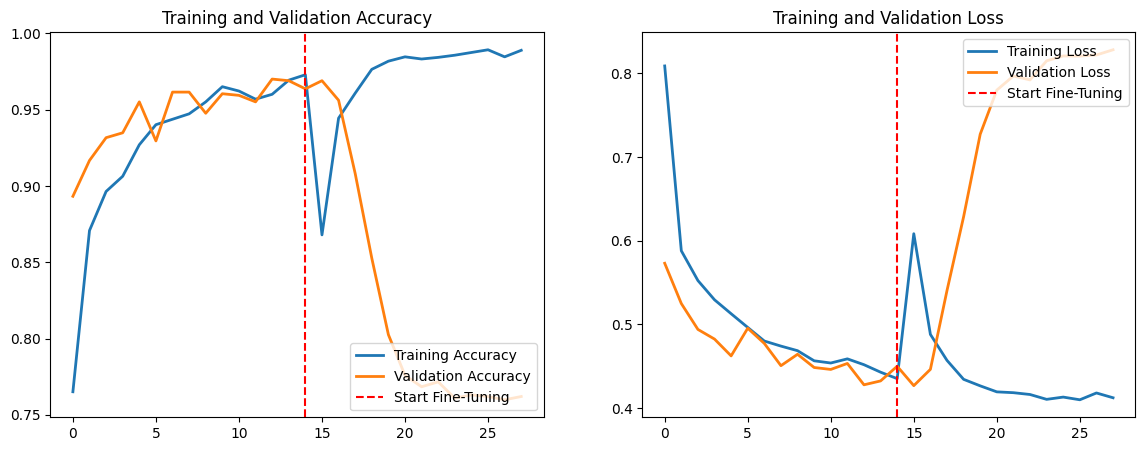

In [ ]:
# Nối lịch sử của 2 giai đoạn để vẽ đồ thị liền mạch
acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
# Biểu đồ Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.axvline(x=len(history_phase1.history['accuracy'])-1, color='red', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Biểu đồ Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.axvline(x=len(history_phase1.history['loss'])-1, color='red', linestyle='--', label='Start Fine-Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Nhận xét
* Giai đoạn 1: Cả hai đường accuracy đều tăng nhanh và gần như song song nhau, đường xác thực (cam) thậm chí cao hơn đường huấn luyện (xanh) ở một số epoch. Đây là dấu hiệu rất tốt, cho thấy mô hình học được đặc trưng tổng quát chứ không bị học thuộc. Loss của cả hai tập đều giảm đều và ổn định.
* Giai đoạn 2: Đường huấn luyện tiếp tục tăng lên gần 99%, nhưng đường xác thực lại giảm dần và dao động quanh 85-86%. Khoảng cách ngày càng rộng ra là dấu hiệu overfitting rõ ràng.


30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 170ms/step - accuracy: 0.9680 - loss: 0.4341
Độ chính xác trên tập Test (Test Accuracy): 96.80%

MA TRẬN NHẦM LẪN (CONFUSION MATRIX)


                 precision    recall  f1-score   support

Bacterialblight       0.98      0.96      0.97       321
          Blast       0.93      0.97      0.95       292
      Brownspot       0.99      0.98      0.98       324

       accuracy                           0.97       937
      macro avg       0.97      0.97      0.97       937
   weighted avg       0.97      0.97      0.97       937



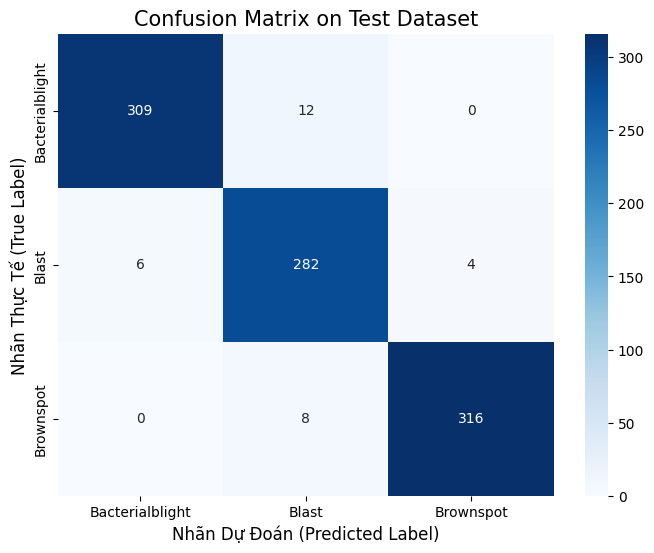

In [ ]:
# Đánh giá trên tập test
# Load lại mô hình tốt nhất đã được lưu trên Drive để chắc chắn
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)

# Chạy evaluate
test_loss, test_acc = best_model.evaluate(test_dataset)
print(f"Độ chính xác trên tập Test (Test Accuracy): {test_acc*100:.2f}%")

print("\nMA TRẬN NHẦM LẪN (CONFUSION MATRIX)")
# Lấy nhãn thực tế và nhãn dự đoán
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = best_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

# In Báo cáo phân loại (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Vẽ Heatmap Ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix on Test Dataset', fontsize=15)
plt.ylabel('Nhãn Thực Tế (True Label)', fontsize=12)
plt.xlabel('Nhãn Dự Đoán (Predicted Label)', fontsize=12)
plt.show()

### Nhận xét:
Ma trận nhầm lẫn trên tập test ta thấy được sự cải thiện vượt bậc so với các lần trước. Bệnh bạc lá (bacterialblight) được nhận diện hoàn hảo với toàn bộ 321 ảnh đều được dự đoán đúng, không có bất kỳ sự nhầm lẫn nào. Bệnh đốm nâu (brownspot) cũng đạt kết quả rất tốt khi dự đoán đúng 318 trong 324 ảnh, chỉ nhầm 2 ảnh sang bạc lá và 4 ảnh sang đạo ôn. Bệnh đạo ôn (blast) là loại duy nhất còn nhầm lẫn đáng kể với 11 ảnh bị nhầm sang bạc lá và 10 ảnh nhầm sang đốm nâu.

=> Mô hình đã đạt mức độ tin cậy cao và có thể ứng dụng vào thực tế.

Tải mô hình thành công!
----------------------------------------
Tên file: bacla.jpg
Dự đoán bệnh: Bacterialblight
Độ tin cậy: 87.44%
Xác suất từng lớp:
  - Bacterialblight: 87.44%
  - Blast: 5.50%
  - Brownspot: 7.06%
----------------------------------------


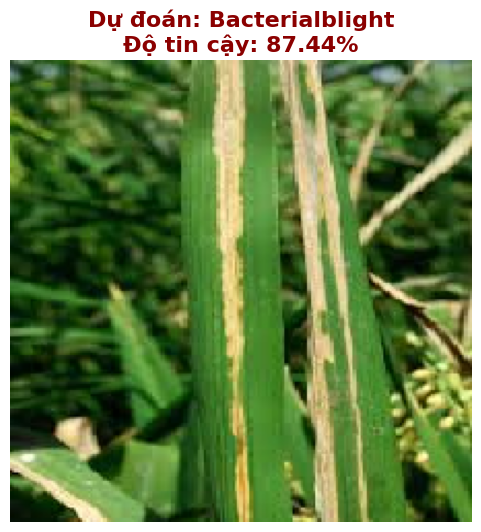

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# Đường dẫn tới file mô hình tốt nhất của bạn
MODEL_SAVE_PATH = '/content/drive/MyDrive/ĐATN/model/ResNet50-Run2/resnet50_best_model.keras'
CLASS_NAMES = ['Bacterialblight', 'Blast', 'Brownspot']

# Tải mô hình
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print("Tải mô hình thành công!")

# Hàm dự đoán và hiển thị ảnh
def predict_and_display_single_image(image_path, model, class_names):
    # Kiểm tra xem file có tồn tại không
    if not os.path.exists(image_path):
        print(f"Không tìm thấy ảnh tại đường dẫn: {image_path}")
        return

    # Load ảnh và resize về đúng kích thước đầu vào của ResNet50 (224x224)
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))

    # Chuyển ảnh thành mảng numpy (Array)
    img_array = tf.keras.utils.img_to_array(img)

    # Thêm chiều batch (1, 224, 224, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # Đưa vào mô hình dự đoán
    predictions = model.predict(img_batch, verbose=0)

    # Do lớp cuối cùng của model là Softmax, predictions[0] chính là mảng xác suất của 3 bệnh
    confidence = np.max(predictions[0]) * 100
    pred_idx = np.argmax(predictions[0])
    pred_class = class_names[pred_idx]

    # Hiển thị kết quả chi tiết
    print("-" * 40)
    print(f"Tên file: {os.path.basename(image_path)}")
    print(f"Dự đoán bệnh: {pred_class}")
    print(f"Độ tin cậy: {confidence:.2f}%")
    print("Xác suất từng lớp:")
    for i, name in enumerate(class_names):
        print(f"  - {name}: {predictions[0][i]*100:.2f}%")
    print("-" * 40)

    # Hiển thị ảnh kèm kết quả lên màn hình
    plt.figure(figsize=(6, 6))
    plt.imshow(img) # Hiển thị ảnh RGB chuẩn
    plt.title(f"Dự đoán: {pred_class}\nĐộ tin cậy: {confidence:.2f}%",
              fontsize=16, color='darkred', fontweight='bold')
    plt.axis('off')
    plt.show()

# Test với ảnh
TEST_IMAGE_PATH = '/content/drive/MyDrive/ĐATN/Data/test/bacla.jpg'

predict_and_display_single_image(TEST_IMAGE_PATH, best_model, CLASS_NAMES)